# Exploratory Analysis

## Problems:

Load the NYC AirBnB Truncated Dataset. This dataset is a mirror of the full NYC AirBnB dataset found at Kaggle, but only contains the first 10,000 entries. 

https://www.kaggle.com/dgomonov/new-york-city-airbnb-open-data

For the numerical features, 

1) Display histograms for the numerical features. 

2) Construct the scatter plots of price with each of the numerical features.

3) Display the correlation histogram.  

4) Which numerical feature appears to be most predictive of the price?

4) Using numerical features to predict the renting price with linear model. Write down the predict function.

6) Calculate the RSS cost.  

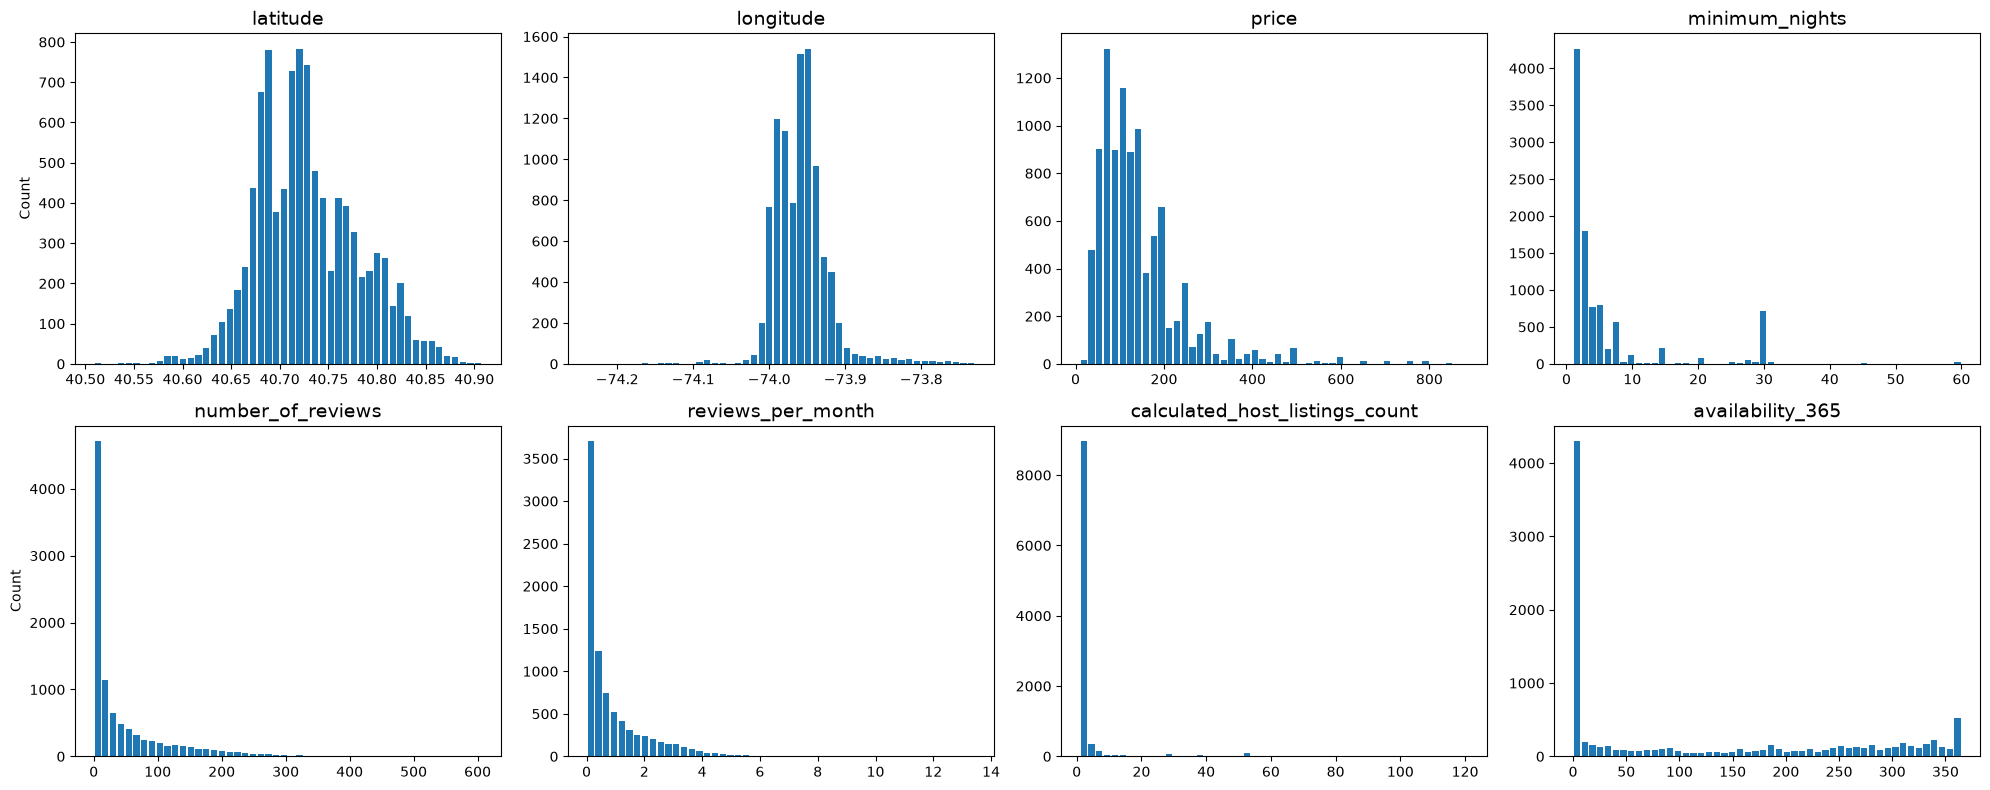

In [15]:
"""
Problem 1: Display histograms for the numerical features.
"""

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

data = pd.read_csv("https://raw.githubusercontent.com/tipthederiver/Math-7243-2020/master/Datasets/NYCAirBnB/train.csv")

nums = data.select_dtypes(include=['int64','float64']).drop(columns=['host_id'])
nnames = list(nums)
num_of_numerical_features = len(list(nums))
z = (nums.price < nums.price.quantile(0.99)) & (nums.minimum_nights <= 60)
numsc = nums[z]

f, axes = plt.subplots(2, 4, figsize=[20, 8])
axes = axes.reshape(-1)

for ax, name in zip(axes, list(numsc)):
    ax.hist(numsc[name].dropna(), bins=50, rwidth=.8)   # reviews_per_month has NaNs
    ax.set_title(name, fontsize=14)
for ax in axes[::4]:
    ax.set_ylabel("Count")

f.tight_layout()
plt.show()

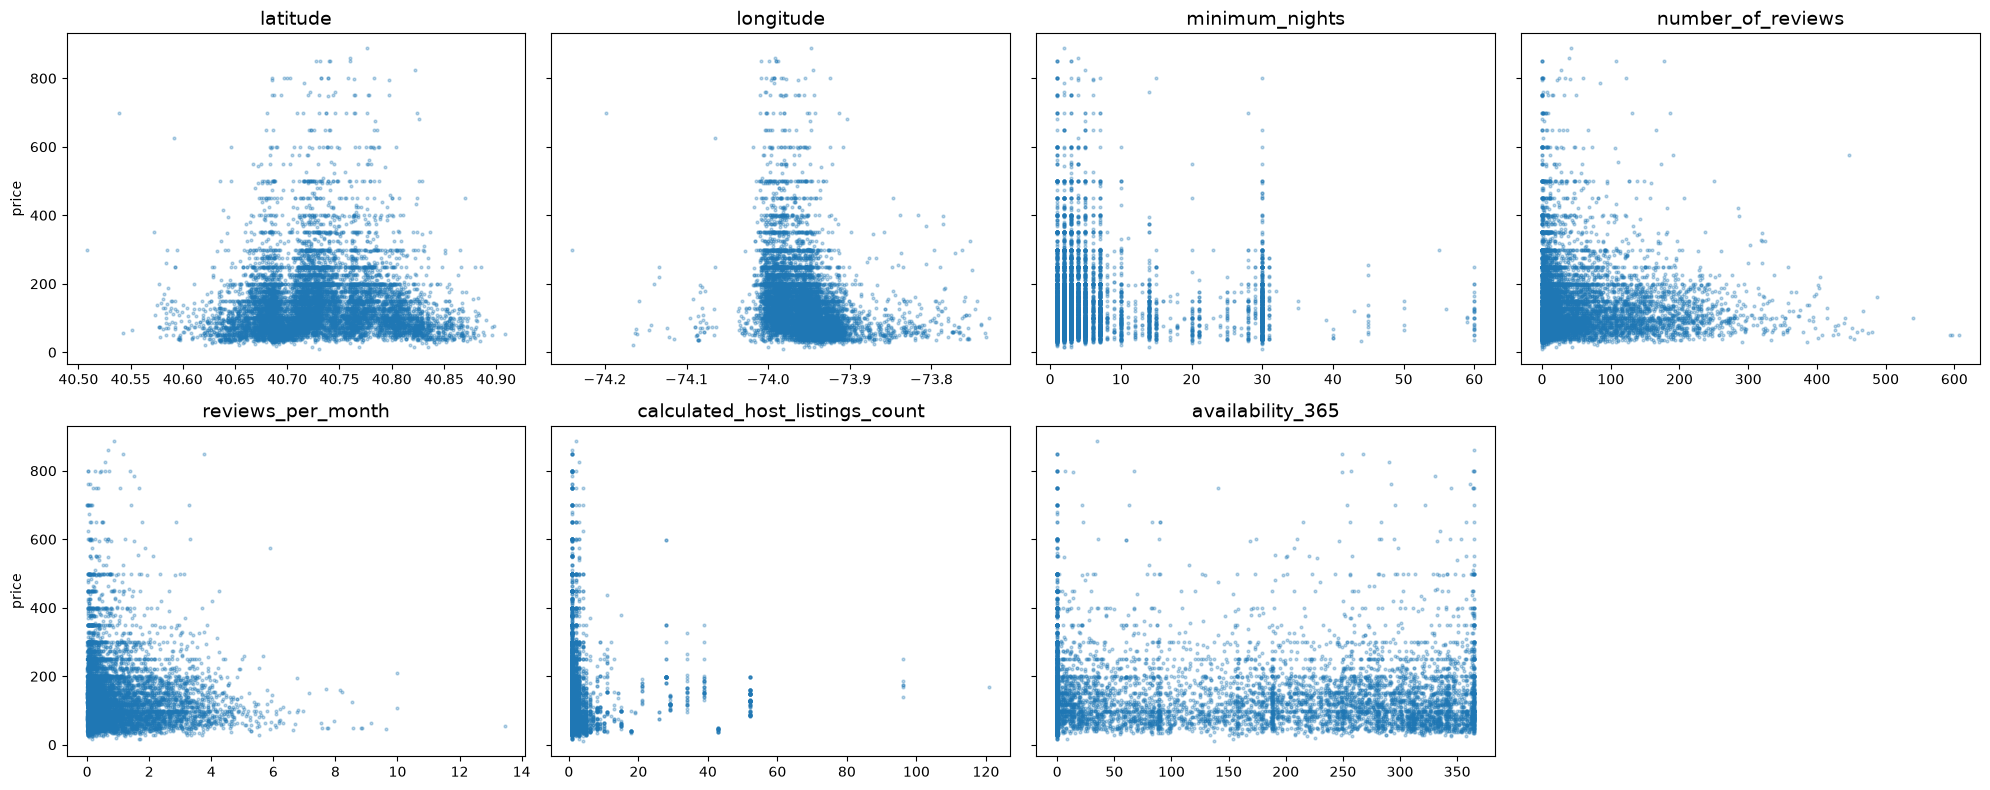

In [16]:
"""
Problem 2: Construct the scatter plots of price with each of the numerical features.
"""

features = [c for c in numsc.columns if c != "price"]  # to not include price vs price
f, axes = plt.subplots(2, 4, sharey=True, figsize=[20, 8])
axes = axes.reshape(-1)

for ax, name in zip(axes, features):
    ax.plot(numsc[name], numsc.price, 'o', markersize=2, alpha=.3)
    ax.set_title(name, fontsize=14)
for ax in axes[::4]:
    ax.set_ylabel("price")
for ax in axes[len(features):]:   # hide unused panel(s)
    ax.set_visible(False)

f.tight_layout()
plt.show()

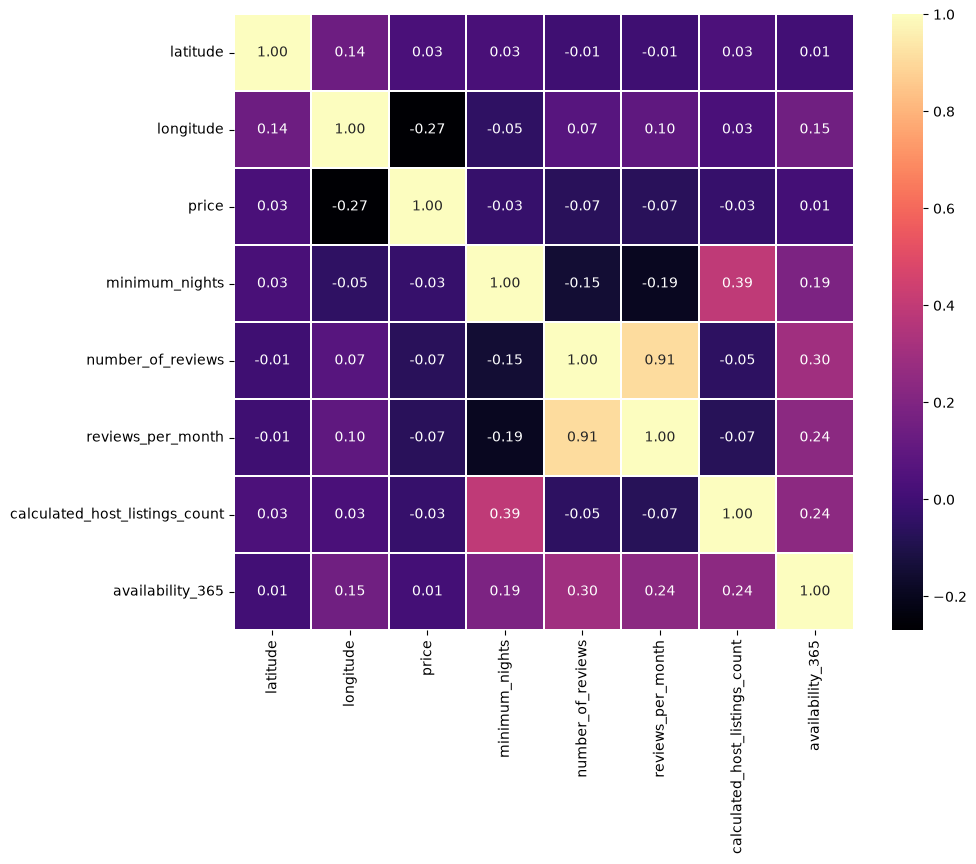

,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
latitude,1.000000,0.137523,0.028952,0.025976,-0.005717,-0.006651,0.033804,0.005166
longitude,0.137523,1.000000,-0.269695,-0.049773,0.069483,0.095438,0.028507,0.149194
price,0.028952,-0.269695,1.000000,-0.030566,-0.067894,-0.071207,-0.027260,0.009399
minimum_nights,0.025976,-0.049773,-0.030566,1.000000,-0.150394,-0.191632,0.391846,0.190647
number_of_reviews,-0.005717,0.069483,-0.067894,-0.150394,1.000000,0.908630,-0.054364,0.296787
reviews_per_month,-0.006651,0.095438,-0.071207,-0.191632,0.908630,1.000000,-0.073289,0.236062
calculated_host_listings_count,0.033804,0.028507,-0.027260,0.391846,-0.054364,-0.073289,1.000000,0.239846
availability_365,0.005166,0.149194,0.009399,0.190647,0.296787,0.236062,0.239846,1.000000


In [23]:
"""
Problem 3: Display the correlation histogram.
"""

import seaborn as sns

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(numsc.corr(), ax=ax, linewidth=.05, cmap="magma", annot=True, fmt=".2f")
plt.show()
numsc.corr()

In [ ]:
"""
Problem 4: Which numerical feature appears to be most predictive of the price?
"""

"""
Answer:

Longitude is the most predictive feature (r ≈ -.27). Listings further west,
in Manhattan, tend to cost more. All other features have |r| < .1, so no
single feature predicts price strongly.
"""

In [30]:
"""
Problem 5: Using numerical features to predict the renting price with linear model. Write down the predict function.
e.g. ŷ = w₀ + w₁x₁ + … + w₇x₇
"""

features = [c for c in numsc.columns if c != "price"]

X = numsc[features].fillna(0).to_numpy()                # NaN reviews_per_month -> 0
X = np.column_stack([np.ones(len(X)), X])               # column of 1s for the intercept w0
y = numsc.price.to_numpy()

w, *_ = np.linalg.lstsq(X, y, rcond=None)

def predict(X):
    return X @ w

for name, wi in zip(["intercept"] + features, w):
    print(f"{name:32s} {wi:10.2f}")

print("""
Therefore, y_hat = 136.49x_1 - 817.01x_2 - .83x_3 - .07x_4 - 4.28x_5 - .33x_6 + .07x_7 - 65836.24
s.t.    y_hat   := price prediction
        x_1     := latitude
        x_2     := longitude
        x_3     := minimum_nights
        x_4     := number_of_reviews
        x_5     := reviews_per_month
        x_6     := calculated_host_listings_count
        x_7     := availability_365
""")

intercept                         -65836.24
latitude                             136.49
longitude                           -817.01
minimum_nights                        -0.83
number_of_reviews                     -0.07
reviews_per_month                     -4.28
calculated_host_listings_count        -0.33
availability_365                       0.07

Therefore, y_hat = 136.49x_1 - 817.01x_2 - .83x_3 - .07x_4 - 4.28x_5 - .33x_6 + .07x_7 - 65836.24
s.t.    y_hat   := price prediction
        x_1     := latitude
        x_2     := longitude
        x_3     := minimum_nights
        x_4     := number_of_reviews
        x_5     := reviews_per_month
        x_6     := calculated_host_listings_count
        x_7     := availability_365



In [33]:
"""
Problem 6: Calculate the RSS cost
"""

rss = np.sum((y - predict(X)) ** 2)
print(f"RSS = {rss:,.2f}")

"""
Seems that the model is a weak fit.
"""

RSS = 92,454,879.10


'\nSeems that the model is a weak fit.\n'